In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv"
df = pd.read_csv(url)
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


# 1. Preprocessing

In [ ]:
df.shape

(37249, 2)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [ ]:
df.isnull().sum()

,0
clean_comment,100
category,0


In [ ]:
df['category'].value_counts()

,count
category,
1,15830
0,13142
-1,8277


In [ ]:
df[df['clean_comment'].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [7]:
# Nan comment pe category ky h
df[df['clean_comment'].isna()]['category'].value_counts()

,count
category,
0,100


In [ ]:
df.dropna(inplace=True)


In [ ]:
# returns no of duplicated rows
df.duplicated().sum()

np.int64(350)

In [10]:
# duplicated rows
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [11]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [12]:
# gives rows where comments are empty or spaces
df[(df['clean_comment'].str.strip() == '')]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [13]:
# deleting empty comments
df = df[~(df['clean_comment'].str.strip() == '')]

In [14]:
# comments ko lower case me convert
df['clean_comment'] = df['clean_comment'].str.lower()
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [15]:
# checking comments starts or ends with spaces or not
df[df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))]


,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [16]:
# Removeing trailing and leading whitespaces
df['clean_comment'] = df['clean_comment'].str.strip()

In [17]:
# checking ke spaces wale comments remove hue ki nhi
df[df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))].sum()


,0
clean_comment,0
category,0


In [18]:
# Identify comments containing URLs
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'

# checking comments containing url or not
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]
comments_with_urls.head()

,clean_comment,category


In [19]:
#checking /n in comments
df[df['clean_comment'].str.contains('\n')]

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1
...,...,...
35128,火箭o辛基 2016 sughosh bansal mission “make india”...,-1
35230,yikes the title should blind bhakts modi hater...,1
36187,hahahahahhahahah \niska klpd hogya,0
36517,्ा् ी ाी े ो ेी ाी े।\nे ी,0


In [20]:
# removing /n from comments
df['clean_comment'] = df['clean_comment'].str.replace('\n',' ', regex=True)

# checking after removing
df[df['clean_comment'].str.contains('\n')]

,clean_comment,category


# EDA

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='category', ylabel='count'>

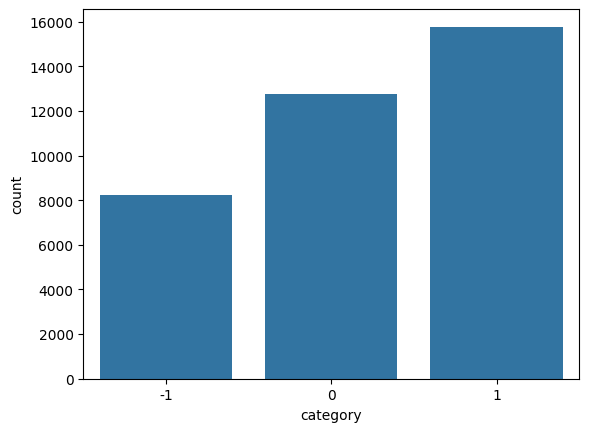

In [22]:
sns.countplot(data=df, x='category')


In [23]:
# percentage of category
df['category'].value_counts(normalize=True).mul(100).round(2)

,proportion
category,
1,42.86
0,34.71
-1,22.42


In [24]:
df['words_count'] = df['clean_comment'].str.split().apply(len)
df.head()

,clean_comment,category,words_count
0,family mormon have never tried explain them th...,1,39
1,buddhism has very much lot compatible with chr...,1,196
2,seriously don say thing first all they won get...,-1,86
3,what you have learned yours and only yours wha...,0,29
4,for your own benefit you may want read living ...,1,112


In [25]:
df['words_count'].describe()

,words_count
count,36793.000000
mean,29.667464
std,56.790738
min,1.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


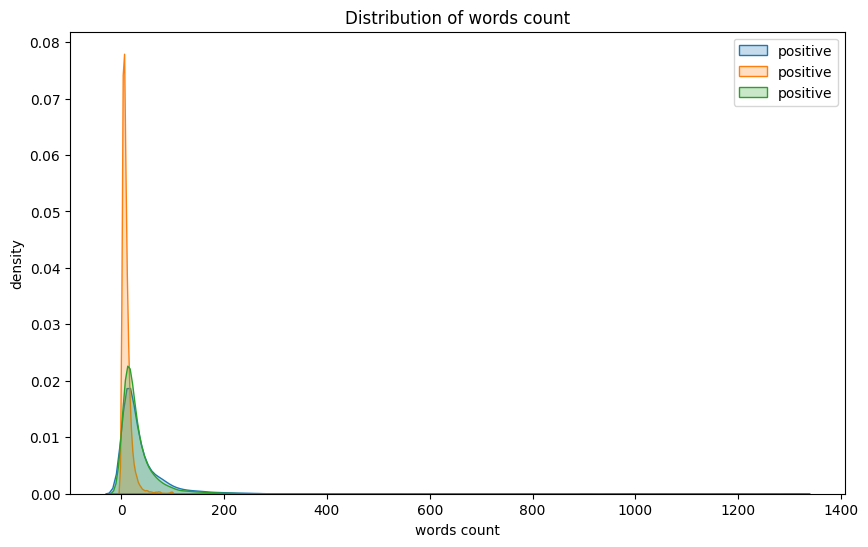

In [26]:
plt.figure(figsize=(10,6))
sns.kdeplot(df[df['category'] == 1]['words_count'], label='positive',fill = True)
sns.kdeplot(df[df['category'] == 0]['words_count'], label='positive',fill = True)
sns.kdeplot(df[df['category'] == -1]['words_count'], label='positive',fill = True)

plt.title('Distribution of words count')
plt.xlabel('words count')
plt.ylabel('density')
plt.legend()


Text(0.5, 1.0, 'Distribution of words count by category')

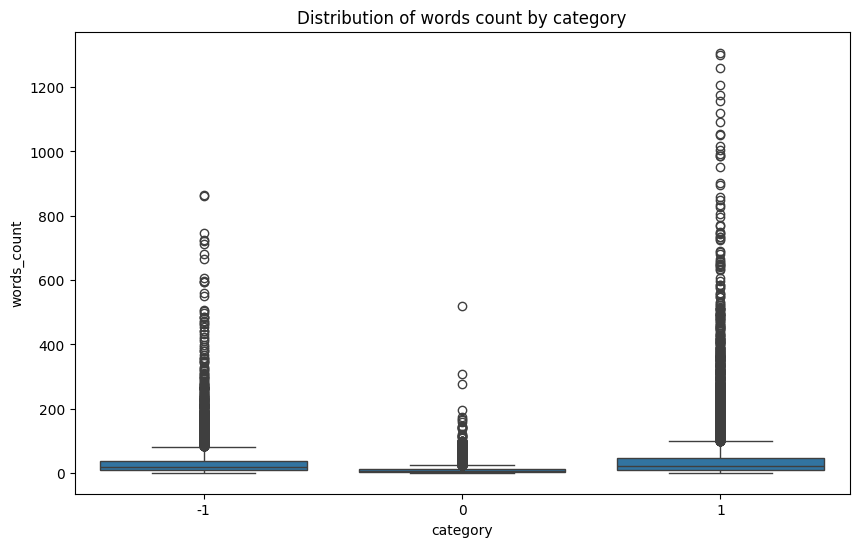

In [28]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='category' , y='words_count')
plt.title('Distribution of words count by category')


Text(0.5, 1.0, 'Scatter of words count by category')

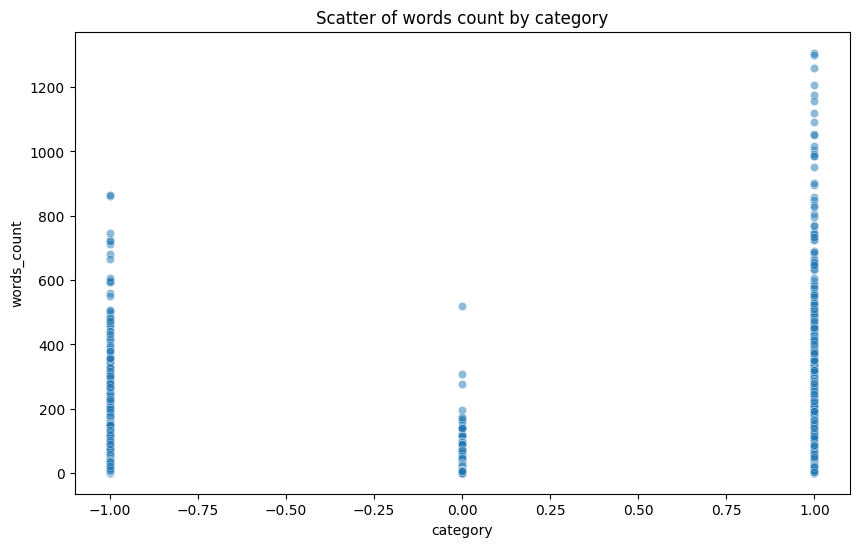

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='category' , y='words_count', alpha = 0.5)
plt.title('Scatter of words count by category')

<Axes: xlabel='category', ylabel='words_count'>

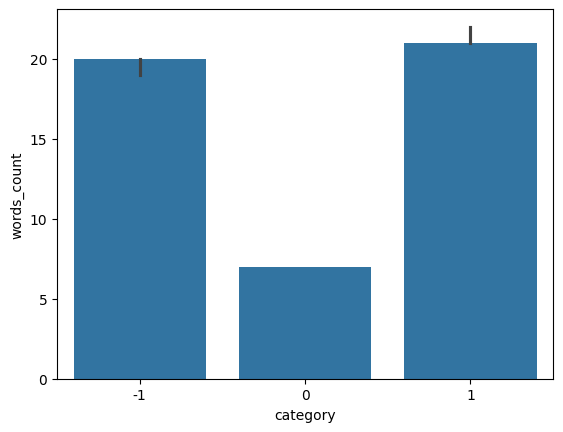

In [29]:
sns.barplot(data=df, x='category' , y='words_count', estimator='median')

In [ ]:
! pip install nltk

In [31]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([words for words in x.split() if words in stop_words]))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [32]:
df.sample(5)

,clean_comment,category,words_count,num_stop_words
34461,pakistan has credibility such things they deni...,0,28,10
29944,wouldn better for everyone involved one looked...,1,29,11
31302,way this through even goes court,0,6,2
20148,are creating history next election slogan,0,6,1
34434,she didn complete her bcom third year per php ...,-1,28,9


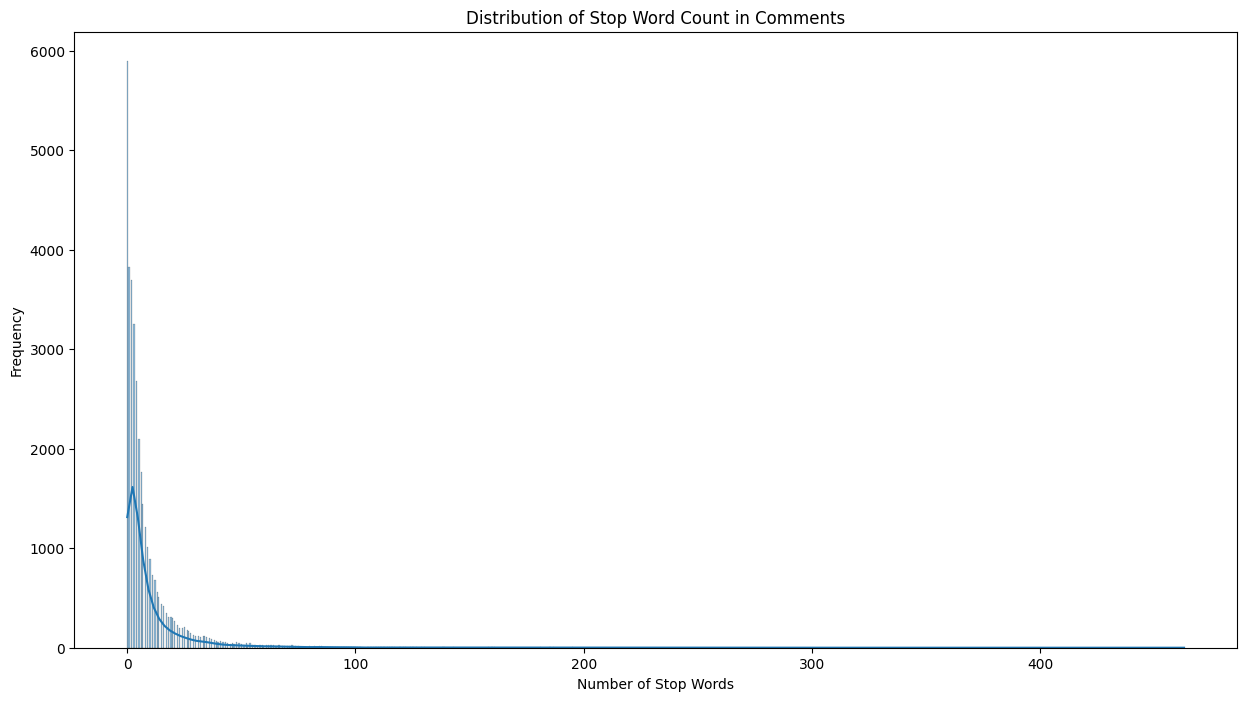

In [34]:
# Create a distribution plot (displot) for the 'num_stop_words' column
plt.figure(figsize=(10, 6))
sns.histplot(df['num_stop_words'], kde=True)
plt.title('Distribution of Stop Word Count in Comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()

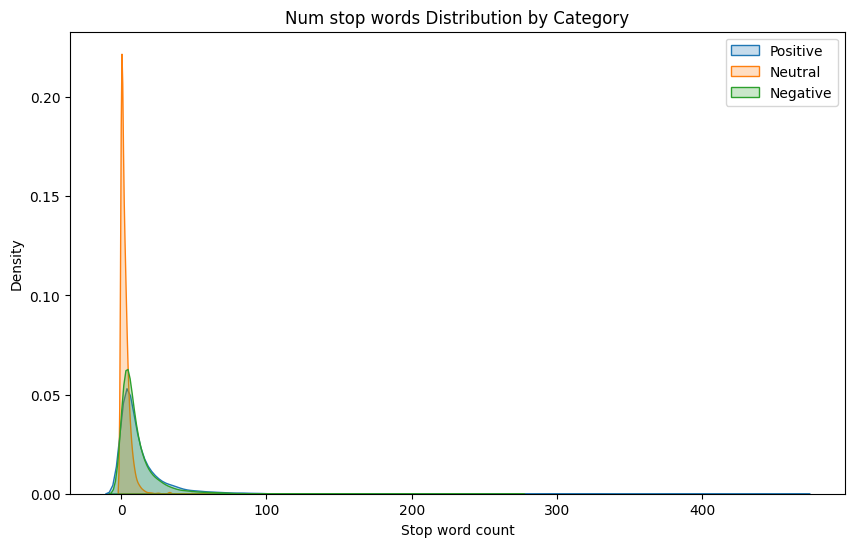

In [ ]:
# Create the figure and axes
plt.figure(figsize=(10, 6))

sns.kdeplot(df[df['category'] == 1]['num_stop_words'], label='Positive', fill=True)

sns.kdeplot(df[df['category'] == 0]['num_stop_words'], label='Neutral', fill=True)

sns.kdeplot(df[df['category'] == -1]['num_stop_words'], label='Negative', fill=True)

plt.title('Num stop words Distribution by Category')
plt.xlabel('Stop word count')
plt.ylabel('Density')

plt.legend()

plt.show()

<Axes: xlabel='category', ylabel='num_stop_words'>

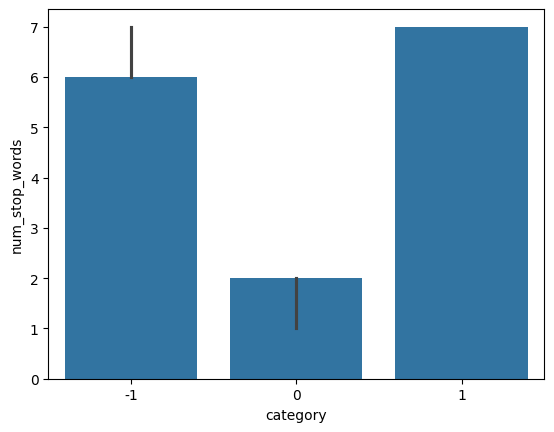

In [ ]:
sns.barplot(data=df, x='category' , y='num_stop_words', estimator='median')

/tmp/ipykernel_174/3351722077.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')


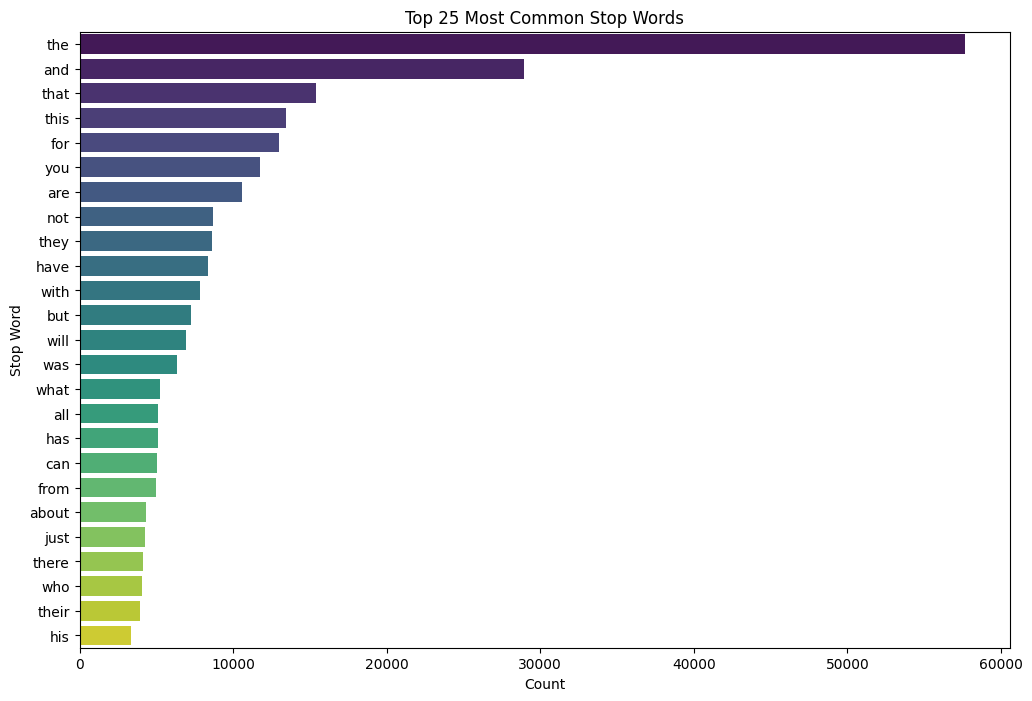

In [ ]:
# Create a frequency distribution of stop words in the 'clean_comment' column
from collections import Counter

all_stop_words = [word for comment in df['clean_comment']
                  for word in comment.split()
                  if word in stop_words]

most_common_stop_words = Counter(all_stop_words).most_common(25)

top_25_df = pd.DataFrame(most_common_stop_words, columns=['stop_word', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')

plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()

In [ ]:
df['num_chars'] = df['clean_comment'].apply(lambda x: len(x))
df

,clean_comment,category,words_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690
...,...,...,...,...,...
37244,jesus,0,1,0,5
37245,kya bhai pure saal chutiya banaya modi aur jab...,1,19,0,99
37246,downvote karna tha par upvote hogaya,0,6,0,36
37247,haha nice,1,2,0,9


In [ ]:
df['num_chars'].describe()

,num_chars
count,36793.000000
mean,181.852798
std,359.702163
min,1.000000
25%,38.000000
50%,80.000000
75%,184.000000
max,8664.000000


In [ ]:
from collections import Counter

# Combine all comments into one large string
all_text = ' '.join(df['clean_comment'])

char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(
    char_frequency.items(),
    columns=['character', 'frequency']
).sort_values(by='frequency', ascending=False)

char_frequency_df.head(50)

In [ ]:
char_frequency_df['character'].values

array([' ', 'e', 't', ..., '段', '她', '谁'], dtype=object)

In [ ]:
char_frequency_df.tail(50)

,character,frequency
1286,货,1
1287,语,1
1312,耐,1
1313,精,1
342,━,1
345,⊂,1
346,゜,1
347,ｊ,1
1289,显,1
1291,鞋,1


In [ ]:
df['num_punctuation_chars'] = df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}-'])
)

df.sample(5)

,clean_comment,category,words_count,num_stop_words,num_chars,num_punctuation_chars
1980,gershon,0,1,0,7,0
36270,thoptv love free forever,1,4,0,24,0
8203,bjp part the state government parrikar tone de...,0,33,12,183,0
16531,wow didn know what was expecting when clicked ...,-1,15,7,82,0
7678,will never vote for congress bjp,0,6,2,32,0


/tmp/ipykernel_174/3125298224.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


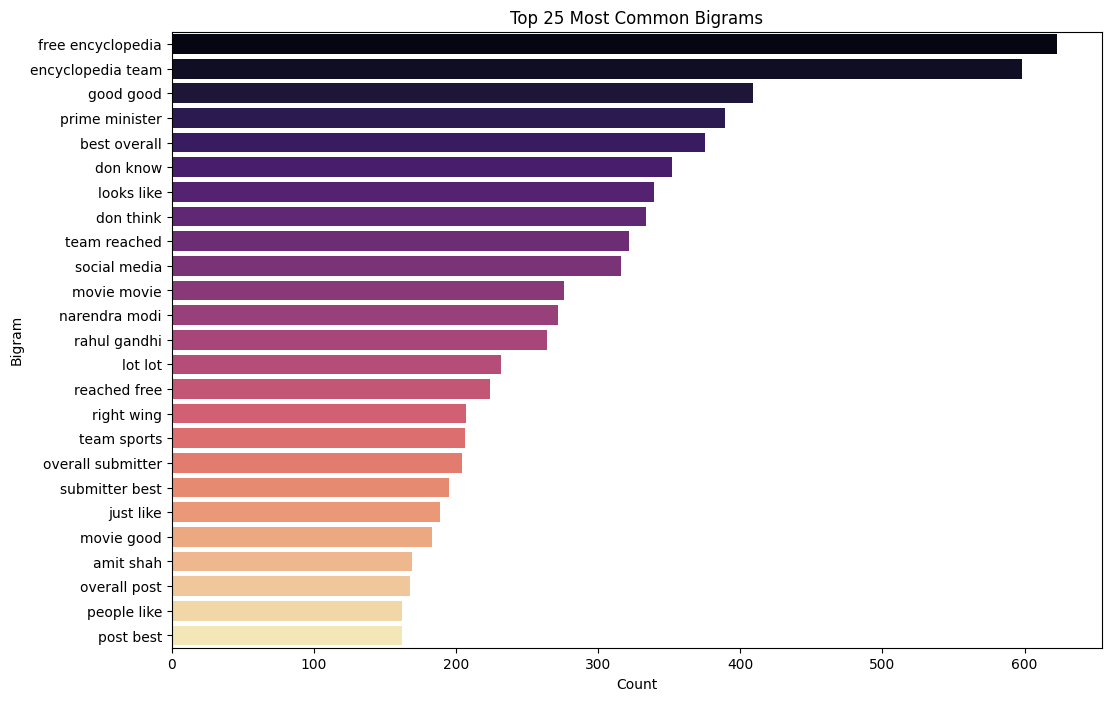

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

top_25_bigrams = get_top_ngrams(df['clean_comment'], 25)
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()


In [ ]:
# Remove non-English characters
import re

df['clean_comment'] = df['clean_comment'].apply(
    lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x))
)

In [ ]:
all_text = ' '.join(df['clean_comment'])

char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(
    char_frequency.items(),
    columns=['character', 'frequency']
).sort_values(by='frequency', ascending=False)

char_frequency_df

,character,frequency
6,,1091592
12,e,666610
13,t,491287
1,a,481134
3,i,401388
9,n,388465
7,o,379908
17,s,355279
8,r,331425
10,h,296748


In [ ]:
from nltk.corpus import stopwords

# Defining stop words
stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}

df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)

In [ ]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

# Applying lemmatization
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...


,clean_comment,category,words_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


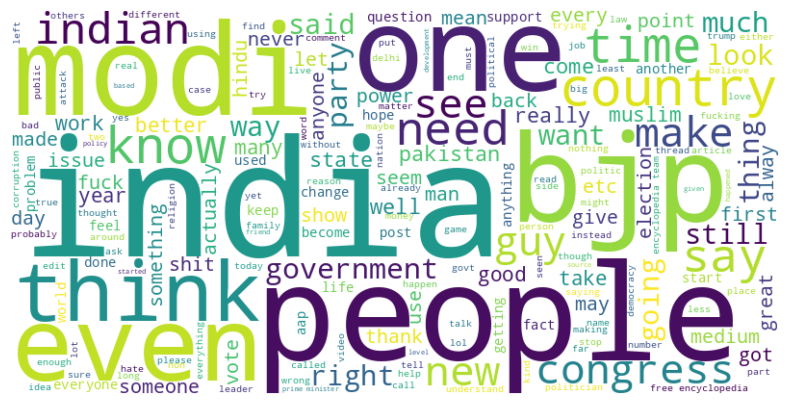

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(' '.join(text))

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df['clean_comment'])

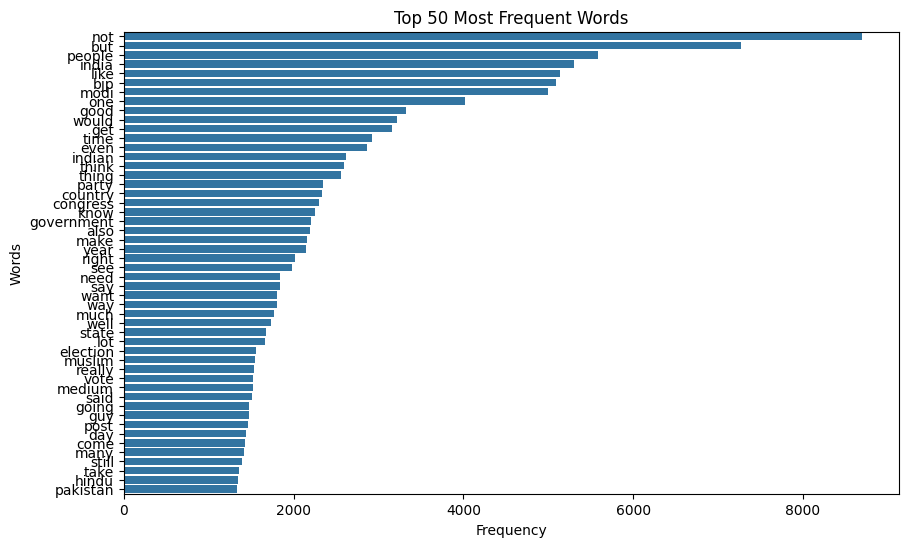

In [ ]:


def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""

    words = ' '.join(df['clean_comment']).split()

    counter = Counter(words)
    most_common_words = counter.most_common(n)

    words, counts = zip(*most_common_words)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()
plot_top_n_words(df, n= 50)

In [ ]:
# converting preprocessed data into csv file
df.to_csv("reddit_preprocessing.csv", index=False)

In [ ]:
# downloaded csv file in system
from google.colab import files
files.download("reddit_preprocessing.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

os.listdir()

['.config', 'reddit_preprocessing.csv', 'sample_data']